In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
df=files.upload()

Saving archive (6).zip to archive (6).zip


In [3]:
df.keys()

dict_keys(['archive (6).zip'])

In [4]:
import zipfile

with zipfile.ZipFile('archive (6).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [5]:
import os
os.listdir()

['.config',
 'campaigns.csv',
 'products.csv',
 'events.csv',
 'customers.csv',
 'transactions.csv',
 'archive (6).zip',
 'sample_data']

In [6]:
events = pd.read_csv("events.csv")
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
products = pd.read_csv("products.csv")
campaigns = pd.read_csv("campaigns.csv")

In [7]:
events.head()

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
0,1,2021-01-14 13:35:43,43812,535101,view,1004.0,desktop,Email,43,PLP,115.1,Control
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.0,desktop,Email,10,PDP,32.4,Variant_A
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532.0,desktop,Paid Search,30,Checkout,134.8,Variant_B
4,5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.1,Variant_A


In [8]:
events.duplicated().sum()

np.int64(0)

In [9]:
events["timestamp"] = pd.to_datetime(events["timestamp"])

In [10]:
events.isnull().sum()

,0
event_id,0
timestamp,0
customer_id,0
session_id,0
event_type,0
product_id,200371
device_type,40300
traffic_source,0
campaign_id,0
page_category,0


In [11]:
events[events["product_id"].isna()]["event_type"].value_counts()

,count
event_type,
bounce,189922
purchase,10449


In [12]:
events["device_type"].value_counts(dropna=False)

,count
device_type,
mobile,1176146
desktop,685433
tablet,98121
NaN,40300


In [13]:
events["device_type"]=(events["device_type"].fillna("unknown"))

In [14]:
events.isnull().sum()

,0
event_id,0
timestamp,0
customer_id,0
session_id,0
event_type,0
product_id,200371
device_type,0
traffic_source,0
campaign_id,0
page_category,0


In [15]:
customers.isnull().sum()

,0
customer_id,0
signup_date,0
country,0
age,0
gender,0
loyalty_tier,0
acquisition_channel,0


In [16]:
transactions.isnull().sum()

,0
transaction_id,0
timestamp,0
customer_id,0
product_id,10449
quantity,0
discount_applied,0
gross_revenue,10449
campaign_id,0
refund_flag,0


In [17]:
funnel_map = {
    'view':'View',
    'add_to_cart':'Cart',
    'checkout':'Checkout',
    'purchase':'Purchase'}
events['funnel_stage'] = (
events['event_type'].map(funnel_map))

In [18]:
events.head()

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group,funnel_stage
0,1,2021-01-14 13:35:43,43812,535101,view,1004.0,desktop,Email,43,PLP,115.1,Control,View
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.0,desktop,Email,10,PDP,32.4,Variant_A,Cart
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A,Purchase
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532.0,desktop,Paid Search,30,Checkout,134.8,Variant_B,Cart
4,5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.1,Variant_A,NaN


In [19]:
stage_num = {
    'View':1,
    'Cart':2,
    'Checkout':3,
    'Purchase':4}
events['stage_num'] = (
events['funnel_stage'].map(stage_num))

In [20]:
purchase_users = (events[events['event_type']=='purchase']
    ['customer_id']
    .unique())
customers['purchased'] = (
customers['customer_id']
.isin(purchase_users).astype(int)
)

In [21]:
session_events = (events.groupby('session_id').size())

In [22]:
session_events

,0
session_id,
1,5
3,3
4,1
5,2
6,2
...,...
666662,1
666663,1
666664,1


In [23]:
products_viewed = (events[events["event_type"] == "product_view"]
                   .groupby("customer_id")["product_id"].nunique()
                   .reset_index(name = "products_viewed"))

In [24]:
cart_count =(events[events["event_type"] == "add_to_cart"].
             groupby("customer_id").size().
             reset_index(name = "cart_count"))

In [25]:
cart_count

,customer_id,cart_count
0,1,1
1,2,3
2,3,4
3,4,1
4,5,1
...,...,...
94223,99996,4
94224,99997,4
94225,99998,2
94226,99999,1


In [26]:
purchase_count = (events[events["event_type"] == "purchase"].
                  groupby("customer_id").size().
                  reset_index(name = "purchase_count"))

In [27]:
purchase_count

,customer_id,purchase_count
0,2,1
1,8,1
2,9,1
3,13,2
4,14,1
...,...,...
64030,99994,1
64031,99995,1
64032,99997,2
64033,99999,3


In [28]:
customer_features = (
    events[["customer_id"]]
    .drop_duplicates())

customer_features = customer_features.merge(
    products_viewed,
    on="customer_id",
    how="left")

customer_features = customer_features.merge(
    cart_count,
    on="customer_id",
    how="left")

customer_features = customer_features.merge(
    purchase_count,
    on="customer_id",
    how="left")

customer_features = customer_features.fillna(0)

In [29]:
customer_features

,customer_id,products_viewed,cart_count,purchase_count
0,43812,0.0,4.0,4.0
1,71340,0.0,3.0,2.0
2,59540,0.0,1.0,1.0
3,3601,0.0,4.0,0.0
4,92735,0.0,4.0,2.0
...,...,...,...,...
99995,1808,0.0,1.0,2.0
99996,59549,0.0,1.0,1.0
99997,43298,0.0,1.0,0.0
99998,54342,0.0,2.0,0.0


In [30]:
total_sessions = (
    events.groupby("customer_id")["session_id"]
    .nunique()
    .reset_index(name="total_sessions"))

In [31]:
total_sessions

,customer_id,total_sessions
0,1,18
1,2,19
2,3,14
3,4,23
4,5,11
...,...,...
99995,99996,16
99996,99997,25
99997,99998,18
99998,99999,23


In [32]:
total_events = (
    events.groupby("customer_id").size()
    .reset_index(name="total_events"))

In [33]:
total_events

,customer_id,total_events
0,1,18
1,2,19
2,3,14
3,4,23
4,5,11
...,...,...
99995,99996,16
99996,99997,25
99997,99998,18
99998,99999,23


In [34]:
session_duration = (
    events.groupby("session_id")["timestamp"]
    .agg(["min", "max"])
    .reset_index()
)
session_duration["session_duration_sec"] = (
    session_duration["max"] - session_duration["min"]
).dt.total_seconds()
session_duration = session_duration[
    ["session_id", "session_duration_sec"]]

events = events.merge(
    session_duration,
    on="session_id",
    how="left")

In [35]:
avg_session_duration = (
    events.groupby("customer_id")["session_duration_sec_y"].mean()
    .reset_index(name="avg_session_duration_sec"))

In [36]:
avg_session_duration

,customer_id,avg_session_duration_sec
0,1,4.856323e+07
1,2,4.933605e+07
2,3,5.467506e+07
3,4,5.625373e+07
4,5,4.627270e+07
...,...,...
99995,99996,4.829703e+07
99996,99997,5.249602e+07
99997,99998,5.878449e+07
99998,99999,4.687292e+07


In [37]:
bounce_session =(
    events[events["event_type"] == "bounce"]
    [["customer_id","session_id"]]
    .drop_duplicates())

In [38]:
bounce_count = (
    bounce_session.groupby("customer_id")
.size()
.reset_index(name="bounce_count"))

In [39]:
bounce_rate_df = total_sessions.merge(
    bounce_count,
    on="customer_id",
    how="left")

In [40]:
bounce_rate_df

,customer_id,total_sessions,bounce_count
0,1,18,NaN
1,2,19,2.0
2,3,14,1.0
3,4,23,3.0
4,5,11,2.0
...,...,...,...
99995,99996,16,1.0
99996,99997,25,3.0
99997,99998,18,1.0
99998,99999,23,3.0


In [41]:
bounce_rate_df["bounce_count"] = (
    bounce_rate_df["bounce_count"]
    .fillna(0))

In [42]:
bounce_rate_df["bounce_rate"] = (
    bounce_rate_df["bounce_count"]
    / bounce_rate_df["total_sessions"])
bounce_rate_df

,customer_id,total_sessions,bounce_count,bounce_rate
0,1,18,0.0,0.000000
1,2,19,2.0,0.105263
2,3,14,1.0,0.071429
3,4,23,3.0,0.130435
4,5,11,2.0,0.181818
...,...,...,...,...
99995,99996,16,1.0,0.062500
99996,99997,25,3.0,0.120000
99997,99998,18,1.0,0.055556
99998,99999,23,3.0,0.130435


In [43]:
purchase_flag = (
    events[events["event_type"] == "purchase"]
    [["customer_id"]].drop_duplicates()
)
purchase_flag["purchased"] = 1
purchase_flag

,customer_id,purchased
2,59540,1
8,54871,1
21,51818,1
31,18164,1
57,86915,1
...,...,...
1999551,66907,1
1999568,43647,1
1999615,77081,1
1999969,91683,1


In [44]:
events["event_type"].value_counts()

,count
event_type,
view,1043573
click,379008
add_to_cart,284370
bounce,189922
purchase,103127


In [45]:
click_count = (events[events["event_type"] == "click"].groupby("customer_id").size()
.reset_index(name="click_count"))

In [46]:
view_count = (events[events["event_type"] == "view"].groupby("customer_id").size()
.reset_index(name="view_count"))

In [47]:
cart_conversion = click_count.merge(
    cart_count,
    on="customer_id",
    how="left")
cart_conversion

,customer_id,click_count,cart_count
0,1,7,1.0
1,2,3,3.0
2,4,7,1.0
3,5,1,1.0
4,6,2,2.0
...,...,...,...
97720,99996,2,4.0
97721,99997,4,4.0
97722,99998,7,2.0
97723,99999,3,1.0


In [48]:
purchase_conversion = cart_count.merge(
    purchase_count,
    on="customer_id",
    how="left")
purchase_conversion

,customer_id,cart_count,purchase_count
0,1,1,NaN
1,2,3,1.0
2,3,4,NaN
3,4,1,NaN
4,5,1,NaN
...,...,...,...
94223,99996,4,NaN
94224,99997,4,2.0
94225,99998,2,NaN
94226,99999,1,3.0


In [49]:
customer_analytics = (
    total_sessions
    .merge(total_events, on='customer_id', how='left')
    .merge(view_count, on='customer_id', how='left')
    .merge(click_count, on='customer_id', how='left')
    .merge(cart_count, on='customer_id', how='left')
    .merge(purchase_count, on='customer_id', how='left')
    .merge(bounce_rate_df[['customer_id','bounce_rate']],
           on='customer_id', how='left'))
customer_analytics

,customer_id,total_sessions,total_events,view_count,click_count,cart_count,purchase_count,bounce_rate
0,1,18,18,10.0,7.0,1.0,NaN,0.000000
1,2,19,19,10.0,3.0,3.0,1.0,0.105263
2,3,14,14,9.0,NaN,4.0,NaN,0.071429
3,4,23,23,12.0,7.0,1.0,NaN,0.130435
4,5,11,11,7.0,1.0,1.0,NaN,0.181818
...,...,...,...,...,...,...,...,...
99995,99996,16,16,9.0,2.0,4.0,NaN,0.062500
99996,99997,25,25,12.0,4.0,4.0,2.0,0.120000
99997,99998,18,18,8.0,7.0,2.0,NaN,0.055556
99998,99999,23,23,13.0,3.0,1.0,3.0,0.130435


In [50]:
customer_analytics["purchase_conversion_rate"] = (
    purchase_conversion["purchase_count"]/ purchase_conversion["cart_count"])
purchase_conversion

,customer_id,cart_count,purchase_count
0,1,1,NaN
1,2,3,1.0
2,3,4,NaN
3,4,1,NaN
4,5,1,NaN
...,...,...,...
94223,99996,4,NaN
94224,99997,4,2.0
94225,99998,2,NaN
94226,99999,1,3.0


In [51]:
customer_analytics["cart_conversion_rate"] = (
cart_conversion["cart_count"]/ cart_conversion["click_count"])
cart_conversion

,customer_id,click_count,cart_count
0,1,7,1.0
1,2,3,3.0
2,4,7,1.0
3,5,1,1.0
4,6,2,2.0
...,...,...,...
97720,99996,2,4.0
97721,99997,4,4.0
97722,99998,7,2.0
97723,99999,3,1.0


In [52]:
customer_analytics = customer_analytics.fillna(0)

In [53]:
customer_analytics.isnull().sum()

,0
customer_id,0
total_sessions,0
total_events,0
view_count,0
click_count,0
cart_count,0
purchase_count,0
bounce_rate,0
purchase_conversion_rate,0
cart_conversion_rate,0


In [54]:
customer_analytics.describe()

,customer_id,total_sessions,total_events,view_count,click_count,cart_count,purchase_count,bounce_rate,purchase_conversion_rate,cart_conversion_rate
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,19.99961,20.000000,10.435730,3.790080,2.843700,1.031270,0.094995,0.441117,0.966593
std,28867.657797,4.45944,4.459639,3.226511,1.945947,1.689147,1.029254,0.067379,0.609987,0.962969
min,1.000000,4.00000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25000.750000,17.00000,17.000000,8.000000,2.000000,2.000000,0.000000,0.047619,0.000000,0.375000
50%,50000.500000,20.00000,20.000000,10.000000,4.000000,3.000000,1.000000,0.088235,0.250000,0.666667
75%,75000.250000,23.00000,23.000000,13.000000,5.000000,4.000000,2.000000,0.136364,0.600000,1.250000
max,100000.000000,41.00000,41.000000,28.000000,14.000000,12.000000,9.000000,0.545455,7.000000,12.000000


In [55]:
customer_analytics["purchased"] = np.where(customer_analytics["purchase_count"] > 0,
                                           1,
                                           0)

In [56]:
customer_analytics["abounded_cart"] = np.where((customer_analytics["cart_count"]> 0) &
(customer_analytics["purchase_count"] == 0) ,1 ,
0                                               )

In [57]:
conditions = [
    customer_analytics["purchase_count"] >= 3,

    (customer_analytics["purchase_count"] >= 1) &
    (customer_analytics["purchase_count"] < 3),
    (customer_analytics["cart_count"] > 0) &
    (customer_analytics["purchase_count"] == 0),
    customer_analytics["bounce_rate"] > 0.3]

choices = [
    "High Value Buyer",
    "Regular Buyer",
    "Cart Abandoner",
    "Bouncer"]

customer_analytics["customer_segment"] = np.select(
    conditions,
    choices,
    default='Browser'
)

In [58]:
customer_analytics

,customer_id,total_sessions,total_events,view_count,click_count,cart_count,purchase_count,bounce_rate,purchase_conversion_rate,cart_conversion_rate,purchased,abounded_cart,customer_segment
0,1,18,18,10.0,7.0,1.0,0.0,0.000000,0.000000,0.142857,0,1,Cart Abandoner
1,2,19,19,10.0,3.0,3.0,1.0,0.105263,0.333333,1.000000,1,0,Regular Buyer
2,3,14,14,9.0,0.0,4.0,0.0,0.071429,0.000000,0.142857,0,1,Cart Abandoner
3,4,23,23,12.0,7.0,1.0,0.0,0.130435,0.000000,1.000000,0,1,Cart Abandoner
4,5,11,11,7.0,1.0,1.0,0.0,0.181818,0.000000,1.000000,0,1,Cart Abandoner
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,16,16,9.0,2.0,4.0,0.0,0.062500,0.000000,0.000000,0,1,Cart Abandoner
99996,99997,25,25,12.0,4.0,4.0,2.0,0.120000,0.000000,0.000000,1,0,Regular Buyer
99997,99998,18,18,8.0,7.0,2.0,0.0,0.055556,0.000000,0.000000,0,1,Cart Abandoner
99998,99999,23,23,13.0,3.0,1.0,3.0,0.130435,0.000000,0.000000,1,0,High Value Buyer


In [59]:
customer_lifetime = (
    events.groupby("customer_id")["timestamp"]
    .agg(["min","max"]).reset_index()
)
customer_lifetime["customer_lifetime_days"] = (customer_lifetime["max"]- customer_lifetime["min"]).dt.days

<Axes: xlabel='customer_segment', ylabel='count'>

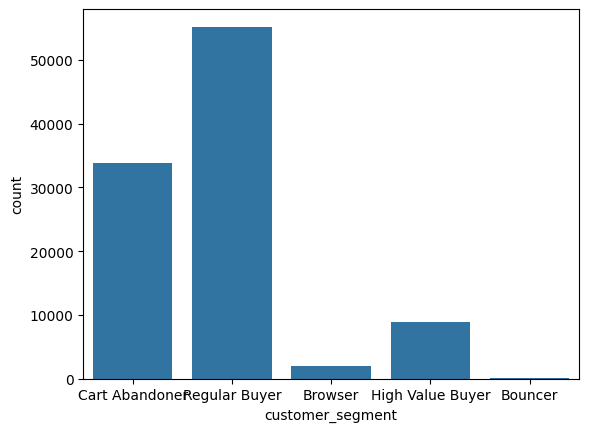

In [60]:
sns.countplot(data=customer_analytics,x="customer_segment")

<Axes: xlabel='purchased', ylabel='view_count'>

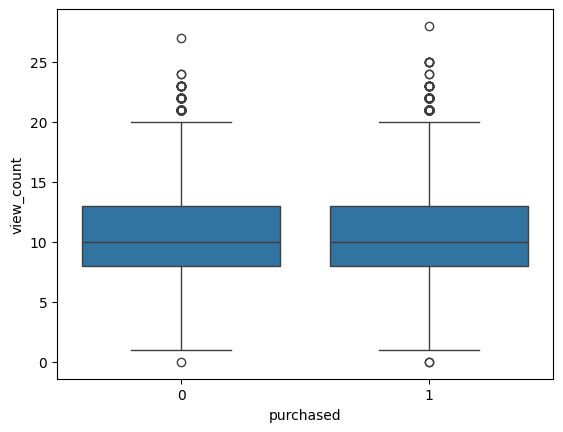

In [61]:
sns.boxplot(x="purchased",y="view_count",data=customer_analytics)

<Axes: xlabel='purchased', ylabel='cart_count'>

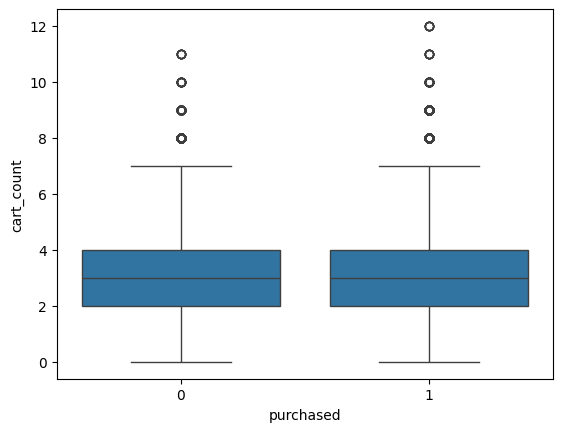

In [62]:
sns.boxplot(x="purchased",y="cart_count",data=customer_analytics)

In [63]:
customer_lifetime

,customer_id,min,max,customer_lifetime_days
0,1,2021-06-13 12:35:27,2023-08-13 08:11:55,790
1,2,2021-01-30 06:32:34,2023-12-30 14:51:13,1064
2,3,2021-06-01 13:37:15,2023-10-24 17:14:26,875
3,4,2021-01-08 09:19:08,2023-12-12 05:16:14,1067
4,5,2021-04-12 04:16:54,2023-12-15 13:21:39,977
...,...,...,...,...
99995,99996,2021-01-04 07:28:17,2023-10-12 00:11:59,1010
99996,99997,2021-01-15 15:16:30,2023-11-05 10:28:44,1023
99997,99998,2021-01-22 19:01:05,2023-12-10 10:09:40,1051
99998,99999,2021-01-22 19:00:02,2023-10-19 02:39:45,999


In [92]:
customer_analytics['click_view_ratio'] = (
    customer_analytics['click_count'] /
    (customer_analytics['view_count'] + 1)
  )
customer_analytics['cart_click_ratio'] = (
    customer_analytics['cart_count'] /
    (customer_analytics['click_count'] + 1))

In [93]:
customer_analytics['engagement_score'] = (
    customer_analytics['view_count']
    + 2*customer_analytics['click_count']
    + 4*customer_analytics['cart_count'])

**MACHINE LEARNING**

In [94]:
X = customer_analytics[
["total_sessions",
"click_view_ratio",
"cart_click_ratio",
"bounce_rate",
"engagement_score"]]

In [95]:
y = customer_analytics["purchased"]

In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000,class_weight="balanced")

log_reg.fit(X_train_scaled,y_train)

y_pred = log_reg.predict(X_test_scaled)

In [102]:
y_pred

array([1, 0, 1, ..., 1, 0, 0])

In [103]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)
print("Accuracy:",
      accuracy_score(y_test,y_pred))

Accuracy: 0.6923


In [83]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.38      0.47      0.42      7193
           1       0.66      0.58      0.62     12807

    accuracy                           0.54     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.56      0.54      0.55     20000



In [84]:
customer_analytics["purchased"].value_counts()

,count
purchased,
1,64035
0,35965


In [86]:
customer_analytics["purchased"].value_counts(normalize=True)

,proportion
purchased,
1,0.64035
0,0.35965


In [88]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]})
coef_df.sort_values(
    by='Coefficient',
    ascending=False)

,Feature,Coefficient
0,total_sessions,4.351319
2,click_count,-4.735763
3,cart_count,-4.742477
1,view_count,-4.750406
4,bounce_rate,-86.021444


In [107]:
import pandas as pd

new_customer = pd.DataFrame({
    "total_sessions": [25],
    "click_view_ratio": [0.5],
    "cart_click_ratio": [0.3],
    "bounce_rate": [0.05],
    "engagement_score": [45]
})
new_customer_scaled = scaler.transform(new_customer)
prediction = log_reg.predict(new_customer_scaled)
if prediction[0] == 1:
    print("Customer is likely to PURCHASE")
else:
    print("Customer is NOT likely to PURCHASE")

Customer is NOT likely to PURCHASE


In [109]:
customer_analytics.to_csv("customer_analytics.csv", index=False)
files.download("customer_analytics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>